In [16]:
import os
import glob
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb
import librosa
from scipy.signal import find_peaks
from scipy.ndimage import median_filter
import subprocess


# =============================================================================
# CONFIGURATION
# =============================================================================
BASE_DIR = r"E:\Research Project (Prof. Preeti Rao)\Top 100 files by Wheeze count"
SMILE_PATH = r"E:\Research Project (Prof. Preeti Rao)\opensmile-3.0-win-x64\bin\SMILExtract.exe"
PITCH_CONFIG = r"E:\Research Project (Prof. Preeti Rao)\opensmile-3.0-win-x64\myconfig\pitch.conf"
OPENSMILE_OUT = r"E:\Research Project (Prof. Preeti Rao)\Classification_24B3907\features_pitch_new"

os.makedirs(OPENSMILE_OUT, exist_ok=True)

WAV_DIR = os.path.join(BASE_DIR, "*.wav")
TXT_DIR = os.path.join(BASE_DIR, "*_label_audacity.txt")

OUT_TRAIN = "csv_train_combined"
OUT_TEST = "csv_test_combined"
os.makedirs(OUT_TRAIN, exist_ok=True)
os.makedirs(OUT_TEST, exist_ok=True)
SMOOTH_WIN = 7   # frames (~70 ms)

SR = 16000
WIN_DUR = 0.025
HOP_DUR = 0.010
FREQ_MAX = 2000

# =============================================================================
# FILE PAIRING
# =============================================================================
wav_files = sorted(glob.glob(WAV_DIR))
txt_files = sorted(glob.glob(TXT_DIR))

wav_stems = {Path(w).stem: w for w in wav_files}
txt_stems = {Path(t).stem.replace('_label_audacity', ''): t for t in txt_files}

pairs = [(wav_stems[k], txt_stems[k]) for k in wav_stems if k in txt_stems]
train_pairs, test_pairs = train_test_split(pairs, test_size=0.2, random_state=42)

# =============================================================================
# LABEL UTILITIES
# =============================================================================
def parse_audacity_labels(txt_path):
    labels = []
    with open(txt_path) as f:
        for line in f:
            p = line.strip().split('\t')
            if len(p) == 3:
                try:
                    s, e = float(p[0]), float(p[1])
                    lab = 1 if 'Wheeze' in p[2] else 0
                    labels.append((s, e, lab))
                except ValueError:
                    pass
    return labels

def wheeze_priority_label(labels, t_start, t_end):
    for s, e, lab in labels:
        if lab == 1 and not (e <= t_start or s >= t_end):
            return 1
    return 0

def enforce_min_wheeze_duration(labels, min_len=10):
    """
    Keep wheeze (1) only if it lasts at least min_len frames.
    """
    labels = labels.copy()
    n = len(labels)
    i = 0

    while i < n:
        if labels[i] == 1:
            start = i
            while i < n and labels[i] == 1:
                i += 1
            end = i
            if (end - start) < min_len:
                labels[start:end] = 0
        else:
            i += 1
    return labels


# def fill_short_zero_gaps(labels, max_gap=4):
#     """
#     Convert short zero gaps between ones to ones.
#     """
#     labels = labels.copy()
#     n = len(labels)
#     i = 0

#     while i < n:
#         if labels[i] == 0:
#             start = i
#             while i < n and labels[i] == 0:
#                 i += 1
#             end = i
#             if start > 0 and end < n:
#                 if labels[start - 1] == 1 and labels[end] == 1:
#                     if (end - start) <= max_gap:
#                         labels[start:end] = 1
#         else:
#             i += 1
#     return labels

def fill_short_zero_gaps(labels, max_gap):
    """
    Convert zero gaps to ones if:
    1) gap length <= max_gap AND
    2) max(number of ones on either side) > number of zeroes
    """
    labels = labels.copy()
    n = len(labels)
    i = 0

    while i < n:
        if labels[i] == 0:
            start = i
            while i < n and labels[i] == 0:
                i += 1
            end = i
            Z = end - start  # zero gap length

            if start > 0 and end < n:
                if labels[start - 1] == 1 and labels[end] == 1:

                    # Count ones to the left
                    L = 0
                    j = start - 1
                    while j >= 0 and labels[j] == 1:
                        L += 1
                        j -= 1

                    # Count ones to the right
                    R = 0
                    j = end
                    while j < n and labels[j] == 1:
                        R += 1
                        j += 1

                    if Z <= max_gap and max(L, R) > Z:
                        labels[start:end] = 1
        else:
            i += 1

    return labels


def suppress_segments_without_low_peaks(preds, n_peaks, peak_thresh=3):
    """
    Remove wheeze segments where no frame has n_peaks < peak_thresh.
    """
    preds = preds.copy()
    n = len(preds)
    i = 0

    while i < n:
        if preds[i] == 1:
            start = i
            while i < n and preds[i] == 1:
                i += 1
            end = i

            # Check if ANY frame in the segment has n_peaks < peak_thresh
            if not np.any(n_peaks[start:end] < peak_thresh):
                preds[start:end] = 0
        else:
            i += 1

    return preds

def extract_pitch_opensmile(wav_path):
    out_csv = os.path.join(
        OPENSMILE_OUT,
        Path(wav_path).stem + ".csv"
    )

    if not os.path.exists(out_csv):
        cmd = [
            SMILE_PATH,
            "-C", PITCH_CONFIG,
            "-I", wav_path,
            "-O", out_csv
        ]
        subprocess.run(cmd, capture_output=True)

        # Fix delimiter
        df = pd.read_csv(out_csv, sep=';')
        df.to_csv(out_csv, index=False)

    return pd.read_csv(out_csv)


# =============================================================================
# FFT FEATURE EXTRACTION (ENHANCED)
# =============================================================================

PITCH_FEATURES = [
    "F0Cand[0]", 
    "F0Cand[1]",
    "candVoicing[0]", 
    "candVoicing[1]",
    "candScores[0]", 
    "candScores[1]",
    # "nCandidates",
    # "candScores[2]", 
    # "candVoicing[2]",
    # "F0Cand[2]"
]

def extract_per_file(wav_path, txt_path):
    audio, _ = librosa.load(wav_path, sr=SR)
    labels = parse_audacity_labels(txt_path)

    # ---- Load openSMILE pitch features ----
    pitch_df = extract_pitch_opensmile(wav_path)

    # Ensure time column exists
    time_col = [c for c in pitch_df.columns if "time" in c.lower()][0]
    pitch_df = pitch_df.rename(columns={time_col: "time_s"})

    win_len = int(WIN_DUR * SR)
    hop_len = int(HOP_DUR * SR)

    rows = []

    for i, start in enumerate(range(0, len(audio) - win_len + 1, hop_len)):
        end = start + win_len
        frame = audio[start:end] * np.hanning(win_len)

        X = np.fft.rfft(frame)
        freqs = np.fft.rfftfreq(win_len, d=1/SR)
        mag = np.abs(X)
        mag[0] = 0

        valid = freqs <= FREQ_MAX
        freqs, mag = freqs[valid], mag[valid]

        # ---- FFT features ----
        idx = np.argmax(mag)
        amp = mag[idx]
        freq = freqs[idx]

        p = mag / (np.sum(mag) + 1e-12)
        spec_entropy = -np.sum(p * np.log(p + 1e-12))

        centroid = np.sum(freqs * mag) / (np.sum(mag) + 1e-12)
        spec_bandwidth = np.sqrt(
            np.sum(((freqs - centroid) ** 2) * mag) / (np.sum(mag) + 1e-12)
        )

        peak_to_mean = amp / (np.mean(mag) + 1e-12)
        peaks, _ = find_peaks(mag, height=0.3 * amp)
        n_peaks = len(peaks)

        # ---- Time ----
        t_start = start / SR
        t_end = end / SR

        # ---- Label ----
        label = wheeze_priority_label(labels, t_start, t_end)

        # ---- Pitch feature alignment ----
        pitch_row = pitch_df.iloc[min(i, len(pitch_df)-1)]

        pitch_values = [
            pitch_row[f] if f in pitch_df.columns else 0.0
            for f in PITCH_FEATURES
        ]

        rows.append([
            Path(wav_path).name,
            t_start,
            # amp,
            # freq,
            # spec_entropy,
            # spec_bandwidth,
            # peak_to_mean,
            # n_peaks,
            *pitch_values,
            label
        ])

    return pd.DataFrame(rows, columns=[
        "file", "time_step_s",
        # "amplitude",
        # "frequency",
        # "spec_entropy",
        # "spec_bandwidth",
        # "peak_to_mean",
        # "n_peaks",
        *PITCH_FEATURES,
        "label"
    ])


# =============================================================================
# PROCESS TRAIN FILES
# =============================================================================
train_frames = []
for wav, txt in train_pairs:
    df = extract_per_file(wav, txt)
    df.to_csv(os.path.join(OUT_TRAIN, Path(wav).stem + "_train.csv"), index=False)
    train_frames.append(df)

train_df = pd.concat(train_frames, ignore_index=True)

# =============================================================================
# PROCESS TEST FILES
# =============================================================================
test_frames = []
for wav, txt in test_pairs:
    df = extract_per_file(wav, txt)
    test_frames.append(df)

test_df = pd.concat(test_frames, ignore_index=True)

# =============================================================================
# MODEL TRAINING
# =============================================================================
feature_cols = [
    # "amplitude", 
    # "frequency",
    # "spec_entropy", 
    # "spec_bandwidth",
    # "peak_to_mean", 
    # "n_peaks",
    *PITCH_FEATURES
]

X_train = train_df[feature_cols].values
y_train = train_df["label"].values
X_test = test_df[feature_cols].values
y_test = test_df["label"].values
# Flip labels: Normal=1, Wheeze=0
# y_train_flipped = 1 - y_train
# y_test_flipped = 1 - y_test

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

n_pos = np.sum(y_train == 1)   # Normal frames
n_neg = np.sum(y_train == 0)   # Wheeze frames

# scale_pos_weight = n_neg / n_pos
# print(f"scale_pos_weight (Normal) = {scale_pos_weight:.2f}")

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.08,
    subsample=0.85,
    colsample_bytree=0.85,
    # scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train_s, y_train)

# =============================================================================
# PREDICTION + TEMPORAL SMOOTHING
# =============================================================================
# Probabilities correspond to flipped "Normal"
test_df["wheeze_prob"] = model.predict_proba(X_test_s)[:, 1]

# Convert back to wheeze probability
# test_df["wheeze_prob"] = 1 - normal_prob

# # ---- Temporal smoothing per file ----
# test_df["wheeze_prob_smooth"] = (
#     test_df.groupby("file")["wheeze_prob"]
#     .transform(lambda x: median_filter(x, size=SMOOTH_WIN))
# )

# ---- Final decision ----
# ---- Initial frame-wise decision ----
test_df["predicted_label_raw"] = (
    test_df["wheeze_prob"] > 0.5
).astype(int)

# ---- Apply temporal constraints per file ----
final_preds = []

for fname, df_f in test_df.groupby("file"):
    preds = df_f["predicted_label_raw"].values
    # peaks = df_f["n_peaks"].values

    # Fill short zero gaps (<= 40 ms)
    preds = fill_short_zero_gaps(preds, max_gap=10)
    
    # Minimum wheeze duration (>= 100 ms)
    preds = enforce_min_wheeze_duration(preds, min_len=15)

    # NEW BIAS: suppress segments without low-peak frames
    # preds = suppress_segments_without_low_peaks(preds,peaks,peak_thresh=6)


    # Re-enforce duration (robustness)
    # preds = enforce_min_wheeze_duration(preds, min_len=10)

    final_preds.append(pd.Series(preds, index=df_f.index))

test_df["predicted_label"] = pd.concat(final_preds).sort_index()

for fname, df_f in test_df.groupby("file"):
    out = os.path.join(OUT_TEST, Path(fname).stem + "_test.csv")
    df_f.to_csv(out, index=False)

# =============================================================================
# METRICS
# =============================================================================
print(classification_report(y_test, test_df["predicted_label"],
                            target_names=["Normal", "Wheeze"]))
print("Confusion Matrix:\n",
      confusion_matrix(y_test, test_df["predicted_label"]))

print("\nDONE")

              precision    recall  f1-score   support

      Normal       0.72      0.61      0.66     10605
      Wheeze       0.80      0.87      0.84     19355

    accuracy                           0.78     29960
   macro avg       0.76      0.74      0.75     29960
weighted avg       0.77      0.78      0.77     29960

Confusion Matrix:
 [[ 6437  4168]
 [ 2449 16906]]

DONE


In [2]:
# =============================================================================
# CNN TEMPORAL MODEL (RUN AFTER XGBOOST PIPELINE)
# =============================================================================
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# -------------------------
# CNN CONFIG
# -------------------------
WIN_SIZE = 100        # 500 ms context
BATCH_SIZE = 256
EPOCHS = 20
LR = 1e-3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CNN_FEATURES = [
    "amplitude", "frequency",
    "spec_entropy", "spec_bandwidth",
    "peak_to_mean", "n_peaks",
    "F0Cand[0]", "F0Cand[1]", "F0Cand[2]",
    "candVoicing[0]", "candVoicing[1]","candVoicing[2]",
    "candScores[0]", "candScores[1]", "candScores[2]",
    "nCandidates"
]

# -------------------------
# WINDOWING FUNCTION
# -------------------------
def make_windows(df, feature_cols, win_size):
    X, y = [], []
    for _, df_f in df.groupby("file"):
        feats = df_f[feature_cols].values
        labels = df_f["label"].values

        for i in range(len(df_f) - win_size + 1):
            X.append(feats[i:i+win_size])
            y.append(labels[i + win_size // 2])

    return np.array(X), np.array(y)

# -------------------------
# PREPARE DATA
# -------------------------
X_train_cnn, y_train_cnn = make_windows(train_df, CNN_FEATURES, WIN_SIZE)
X_test_cnn, y_test_cnn = make_windows(test_df, CNN_FEATURES, WIN_SIZE)

scaler_cnn = StandardScaler()
X_train_cnn = scaler_cnn.fit_transform(
    X_train_cnn.reshape(-1, X_train_cnn.shape[-1])
).reshape(X_train_cnn.shape)

X_test_cnn = scaler_cnn.transform(
    X_test_cnn.reshape(-1, X_test_cnn.shape[-1])
).reshape(X_test_cnn.shape)

# (batch, channels, time)
X_train_cnn = np.transpose(X_train_cnn, (0, 2, 1))
X_test_cnn = np.transpose(X_test_cnn, (0, 2, 1))

# -------------------------
# TORCH DATASET
# -------------------------
class WheezeDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = WheezeDataset(X_train_cnn, y_train_cnn)
test_ds = WheezeDataset(X_test_cnn, y_test_cnn)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

# -------------------------
# CNN MODEL
# -------------------------
class WheezeCNN(nn.Module):
    def __init__(self, n_feats):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(n_feats, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.net(x)

model = WheezeCNN(n_feats=len(CNN_FEATURES)).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# -------------------------
# TRAINING LOOP
# -------------------------
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0

    for Xb, yb in train_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)

        optimizer.zero_grad()
        out = model(Xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"[CNN] Epoch {epoch+1}/{EPOCHS} | Loss: {epoch_loss:.4f}")

# -------------------------
# EVALUATION
# -------------------------
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(DEVICE)
        logits = model(Xb)
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        y_true.extend(yb.numpy())
        y_pred.extend(preds)

print("\nCNN CLASSIFICATION REPORT")
print(classification_report(y_true, y_pred, target_names=["Normal", "Wheeze"]))

print("CNN CONFUSION MATRIX")
print(confusion_matrix(y_true, y_pred))

print("\nCNN PIPELINE DONE")


[CNN] Epoch 1/20 | Loss: 207.4529
[CNN] Epoch 2/20 | Loss: 176.4680
[CNN] Epoch 3/20 | Loss: 158.2657
[CNN] Epoch 4/20 | Loss: 143.3715
[CNN] Epoch 5/20 | Loss: 130.3299
[CNN] Epoch 6/20 | Loss: 118.7577
[CNN] Epoch 7/20 | Loss: 110.0921
[CNN] Epoch 8/20 | Loss: 101.9809
[CNN] Epoch 9/20 | Loss: 96.1367
[CNN] Epoch 10/20 | Loss: 91.6020
[CNN] Epoch 11/20 | Loss: 88.6382
[CNN] Epoch 12/20 | Loss: 83.1838
[CNN] Epoch 13/20 | Loss: 81.6855
[CNN] Epoch 14/20 | Loss: 78.2573
[CNN] Epoch 15/20 | Loss: 76.1189
[CNN] Epoch 16/20 | Loss: 72.6055
[CNN] Epoch 17/20 | Loss: 70.6625
[CNN] Epoch 18/20 | Loss: 68.8960
[CNN] Epoch 19/20 | Loss: 66.0020
[CNN] Epoch 20/20 | Loss: 65.3201

CNN CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal       0.62      0.61      0.61      8204
      Wheeze       0.84      0.84      0.84     19636

    accuracy                           0.77     27840
   macro avg       0.73      0.73      0.73     27840
weighted avg       0.7

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb
import librosa
from scipy.signal import find_peaks
from scipy.ndimage import median_filter
import subprocess


# =============================================================================
# CONFIGURATION
# =============================================================================
BASE_DIR = r"E:\Research Project (Prof. Preeti Rao)\Top 100 files by Wheeze count"
SMILE_PATH = r"E:\Research Project (Prof. Preeti Rao)\opensmile-3.0-win-x64\bin\SMILExtract.exe"
PITCH_CONFIG = r"E:\Research Project (Prof. Preeti Rao)\opensmile-3.0-win-x64\myconfig\pitch.conf"
OPENSMILE_OUT = r"E:\Research Project (Prof. Preeti Rao)\Classification_24B3907\features_pitch_new"

os.makedirs(OPENSMILE_OUT, exist_ok=True)

WAV_DIR = os.path.join(BASE_DIR, "*.wav")
TXT_DIR = os.path.join(BASE_DIR, "*_label_audacity.txt")

OUT_TRAIN = "csv_train_combined"
OUT_TEST = "csv_test_combined"
os.makedirs(OUT_TRAIN, exist_ok=True)
os.makedirs(OUT_TEST, exist_ok=True)
SMOOTH_WIN = 7   # frames (~70 ms)

SR = 16000
WIN_DUR = 0.100
HOP_DUR = 0.010
FREQ_MAX = 2000

# =============================================================================
# FILE PAIRING
# =============================================================================
wav_files = sorted(glob.glob(WAV_DIR))
txt_files = sorted(glob.glob(TXT_DIR))

wav_stems = {Path(w).stem: w for w in wav_files}
txt_stems = {Path(t).stem.replace('_label_audacity', ''): t for t in txt_files}

pairs = [(wav_stems[k], txt_stems[k]) for k in wav_stems if k in txt_stems]
train_pairs, test_pairs = train_test_split(pairs, test_size=0.2, random_state=42)

# =============================================================================
# LABEL UTILITIES
# =============================================================================
def parse_audacity_labels(txt_path):
    labels = []
    with open(txt_path) as f:
        for line in f:
            p = line.strip().split('\t')
            if len(p) == 3:
                try:
                    s, e = float(p[0]), float(p[1])
                    lab = 1 if 'Wheeze' in p[2] else 0
                    labels.append((s, e, lab))
                except ValueError:
                    pass
    return labels

def wheeze_overlap_ratio(labels, t_start, t_end, min_ratio=0.4):
    overlap = 0.0
    dur = t_end - t_start

    for s, e, lab in labels:
        if lab == 1:
            overlap += max(0, min(e, t_end) - max(s, t_start))

    return 1 if (overlap / dur) >= min_ratio else 0

def wheeze_priority_label(labels, t_start, t_end):
    for s, e, lab in labels:
        if lab == 1 and not (e <= t_start or s >= t_end):
            return 1
    return 0

def enforce_min_wheeze_duration(labels, min_len=10):
    """
    Keep wheeze (1) only if it lasts at least min_len frames.
    """
    labels = labels.copy()
    n = len(labels)
    i = 0

    while i < n:
        if labels[i] == 1:
            start = i
            while i < n and labels[i] == 1:
                i += 1
            end = i
            if (end - start) < min_len:
                labels[start:end] = 0
        else:
            i += 1
    return labels


def fill_short_zero_gaps(labels, max_gap=4):
    """
    Convert short zero gaps between ones to ones.
    """
    labels = labels.copy()
    n = len(labels)
    i = 0

    while i < n:
        if labels[i] == 0:
            start = i
            while i < n and labels[i] == 0:
                i += 1
            end = i
            if start > 0 and end < n:
                if labels[start - 1] == 1 and labels[end] == 1:
                    if (end - start) <= max_gap:
                        labels[start:end] = 1
        else:
            i += 1
    return labels

def suppress_segments_without_low_peaks(preds, n_peaks, peak_thresh=3):
    """
    Remove wheeze segments where no frame has n_peaks < peak_thresh.
    """
    preds = preds.copy()
    n = len(preds)
    i = 0

    while i < n:
        if preds[i] == 1:
            start = i
            while i < n and preds[i] == 1:
                i += 1
            end = i

            # Check if ANY frame in the segment has n_peaks < peak_thresh
            if not np.any(n_peaks[start:end] < peak_thresh):
                preds[start:end] = 0
        else:
            i += 1

    return preds

def extract_pitch_opensmile(wav_path):
    out_csv = os.path.join(
        OPENSMILE_OUT,
        Path(wav_path).stem + ".csv"
    )

    if not os.path.exists(out_csv):
        cmd = [
            SMILE_PATH,
            "-C", PITCH_CONFIG,
            "-I", wav_path,
            "-O", out_csv
        ]
        subprocess.run(cmd, capture_output=True)

        # Fix delimiter
        df = pd.read_csv(out_csv, sep=';')
        df.to_csv(out_csv, index=False)

    return pd.read_csv(out_csv)


# =============================================================================
# FFT FEATURE EXTRACTION (ENHANCED)
# =============================================================================

PITCH_FEATURES = [
    "F0Cand[0]", "F0Cand[1]",
    "candVoicing[0]", "candVoicing[1]",
    "candScores[0]", "candScores[1]","nCandidates",
    "candScores[2]", "candVoicing[2]","F0Cand[2]"
]

def extract_per_file(wav_path, txt_path):
    audio, _ = librosa.load(wav_path, sr=SR)
    labels = parse_audacity_labels(txt_path)

    # ---- Load openSMILE pitch features ----
    pitch_df = extract_pitch_opensmile(wav_path)

    # Ensure time column exists
    time_col = [c for c in pitch_df.columns if "time" in c.lower()][0]
    pitch_df = pitch_df.rename(columns={time_col: "time_s"})

    win_len = int(WIN_DUR * SR)
    hop_len = int(HOP_DUR * SR)

    rows = []

    for i, start in enumerate(range(0, len(audio) - win_len + 1, hop_len)):
        end = start + win_len
        frame = audio[start:end] * np.hanning(win_len)

        X = np.fft.rfft(frame)
        freqs = np.fft.rfftfreq(win_len, d=1/SR)
        mag = np.abs(X)
        mag[0] = 0

        valid = freqs <= FREQ_MAX
        freqs, mag = freqs[valid], mag[valid]

        # ---- FFT features ----
        idx = np.argmax(mag)
        amp = mag[idx]
        freq = freqs[idx]

        p = mag / (np.sum(mag) + 1e-12)
        spec_entropy = -np.sum(p * np.log(p + 1e-12))

        centroid = np.sum(freqs * mag) / (np.sum(mag) + 1e-12)
        spec_bandwidth = np.sqrt(
            np.sum(((freqs - centroid) ** 2) * mag) / (np.sum(mag) + 1e-12)
        )

        peak_to_mean = amp / (np.mean(mag) + 1e-12)
        peaks, _ = find_peaks(mag, height=0.3 * amp)
        n_peaks = len(peaks)

        # ---- Time ----
        t_start = start / SR
        t_end = end / SR

        # ---- Label ----
        label = wheeze_overlap_ratio(labels, t_start, t_end)

        # ---- Pitch feature alignment ----
        pitch_row = pitch_df.iloc[min(i, len(pitch_df)-1)]

        pitch_values = [
            pitch_row[f] if f in pitch_df.columns else 0.0
            for f in PITCH_FEATURES
        ]

        rows.append([
            Path(wav_path).name,
            t_start,
            amp,
            freq,
            spec_entropy,
            spec_bandwidth,
            peak_to_mean,
            n_peaks,
            *pitch_values,
            label
        ])

    return pd.DataFrame(rows, columns=[
        "file", "time_step_s",
        "amplitude", "frequency",
        "spec_entropy", "spec_bandwidth",
        "peak_to_mean", "n_peaks",
        *PITCH_FEATURES,
        "label"
    ])


# =============================================================================
# PROCESS TRAIN FILES
# =============================================================================
train_frames = []
for wav, txt in train_pairs:
    df = extract_per_file(wav, txt)
    df.to_csv(os.path.join(OUT_TRAIN, Path(wav).stem + "_train.csv"), index=False)
    train_frames.append(df)

train_df = pd.concat(train_frames, ignore_index=True)

# =============================================================================
# PROCESS TEST FILES
# =============================================================================
test_frames = []
for wav, txt in test_pairs:
    df = extract_per_file(wav, txt)
    test_frames.append(df)

test_df = pd.concat(test_frames, ignore_index=True)

# =============================================================================
# MODEL TRAINING
# =============================================================================
feature_cols = [
    "amplitude", "frequency",
    "spec_entropy", "spec_bandwidth",
    "peak_to_mean", "n_peaks",*PITCH_FEATURES
]

X_train = train_df[feature_cols].values
y_train = train_df["label"].values
X_test = test_df[feature_cols].values
y_test = test_df["label"].values
# Flip labels: Normal=1, Wheeze=0
# y_train_flipped = 1 - y_train
# y_test_flipped = 1 - y_test

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

n_pos = np.sum(y_train == 1)   # Normal frames
n_neg = np.sum(y_train == 0)   # Wheeze frames

# scale_pos_weight = n_neg / n_pos
# print(f"scale_pos_weight (Normal) = {scale_pos_weight:.2f}")

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.08,
    subsample=0.85,
    colsample_bytree=0.85,
    # scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train_s, y_train)

# =============================================================================
# PREDICTION + TEMPORAL SMOOTHING
# =============================================================================
# Probabilities correspond to flipped "Normal"
test_df["wheeze_prob"] = model.predict_proba(X_test_s)[:, 1]

# Convert back to wheeze probability
# test_df["wheeze_prob"] = 1 - normal_prob

# ---- Temporal smoothing per file ----
test_df["wheeze_prob_smooth"] = (
    test_df.groupby("file")["wheeze_prob"]
    .transform(lambda x: median_filter(x, size=SMOOTH_WIN))
)

# ---- Final decision ----
# ---- Initial frame-wise decision ----
test_df["predicted_label_raw"] = (
    test_df["wheeze_prob_smooth"] > 0.5
).astype(int)

# ---- Apply temporal constraints per file ----
final_preds = []

for fname, df_f in test_df.groupby("file"):
    preds = df_f["predicted_label_raw"].values
    peaks = df_f["n_peaks"].values

    # Fill short zero gaps (<= 40 ms)
    preds = fill_short_zero_gaps(preds, max_gap=10)
    
    # Minimum wheeze duration (>= 100 ms)
    preds = enforce_min_wheeze_duration(preds, min_len=15)

    # NEW BIAS: suppress segments without low-peak frames
    preds = suppress_segments_without_low_peaks(preds,peaks,peak_thresh=4)


    # Re-enforce duration (robustness)
    # preds = enforce_min_wheeze_duration(preds, min_len=10)

    final_preds.append(pd.Series(preds, index=df_f.index))

test_df["predicted_label"] = pd.concat(final_preds).sort_index()

for fname, df_f in test_df.groupby("file"):
    out = os.path.join(OUT_TEST, Path(fname).stem + "_test.csv")
    df_f.to_csv(out, index=False)

# =============================================================================
# METRICS
# =============================================================================
print(classification_report(y_test, test_df["predicted_label"],
                            target_names=["Normal", "Wheeze"]))
print("Confusion Matrix:\n",
      confusion_matrix(y_test, test_df["predicted_label"]))

print("\nDONE")

              precision    recall  f1-score   support

      Normal       0.67      0.75      0.71     10542
      Wheeze       0.85      0.80      0.83     19278

    accuracy                           0.78     29820
   macro avg       0.76      0.77      0.77     29820
weighted avg       0.79      0.78      0.78     29820

Confusion Matrix:
 [[ 7886  2656]
 [ 3827 15451]]

DONE


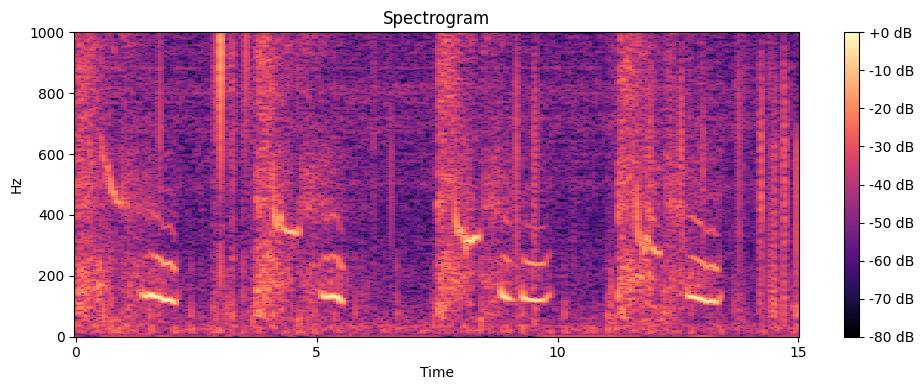

In [21]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# Load audio
wav_path = r"E:\Research Project (Prof. Preeti Rao)\Top 100 files by Wheeze count_mod\steth_20181001_11_01_50.wav"
y, sr = librosa.load(wav_path, sr=None)  # keep original sampling rate

# Compute STFT
S = np.abs(librosa.stft(y, n_fft=1024, hop_length=256))

# Convert to dB
S_db = librosa.amplitude_to_db(S, ref=np.max)

# Plot
plt.figure(figsize=(10, 4))
librosa.display.specshow(
    S_db,
    sr=sr,
    hop_length=256,
    x_axis="time",
    y_axis="hz"
)
plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram")
plt.tight_layout()
plt.ylim(0, 1000)
plt.show()


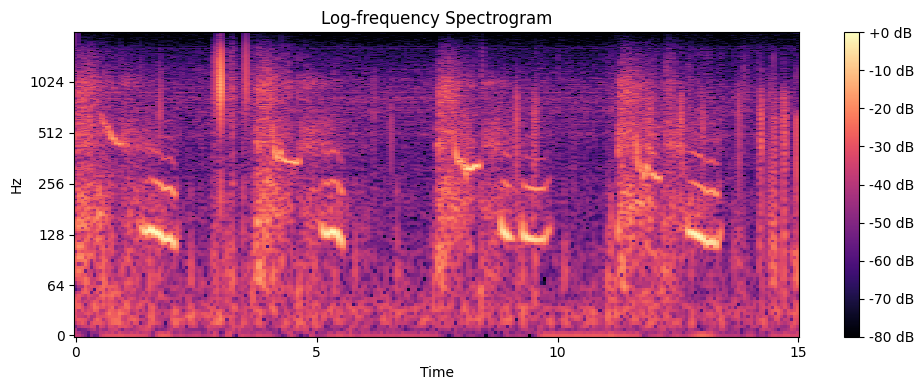

In [17]:
plt.figure(figsize=(10, 4))
librosa.display.specshow(
    S_db,
    sr=sr,
    hop_length=256,
    x_axis="time",
    y_axis="log"
)
plt.colorbar(format="%+2.0f dB")
plt.title("Log-frequency Spectrogram")
plt.tight_layout()
plt.show()


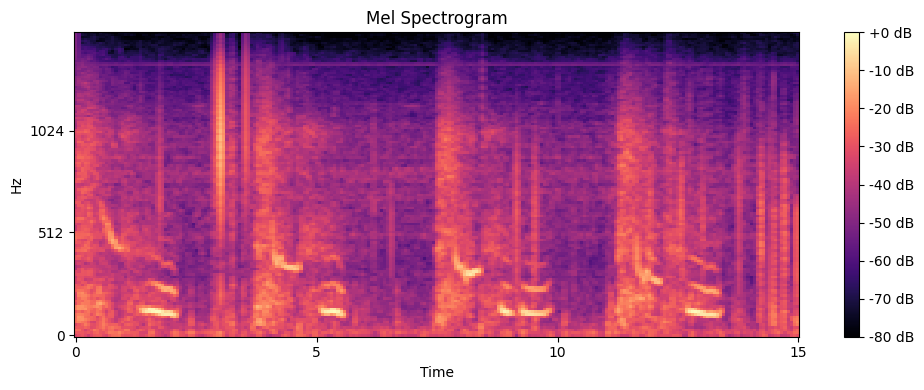

In [20]:
S_mel = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_fft=1024,
    hop_length=256,
    n_mels=128
)

S_mel_db = librosa.power_to_db(S_mel, ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(
    S_mel_db,
    sr=sr,
    hop_length=256,
    x_axis="time",
    y_axis="mel"
)
plt.colorbar(format="%+2.0f dB")
plt.title("Mel Spectrogram")
plt.tight_layout()
plt.show()


In [ ]:
import os
import glob
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb
import librosa
from scipy.signal import find_peaks
from scipy.ndimage import median_filter
import subprocess


# =============================================================================
# CONFIGURATION
# =============================================================================
BASE_DIR = r"E:\Research Project (Prof. Preeti Rao)\Top 100 files by Wheeze count"
SMILE_PATH = r"E:\Research Project (Prof. Preeti Rao)\opensmile-3.0-win-x64\bin\SMILExtract.exe"
PITCH_CONFIG = r"E:\Research Project (Prof. Preeti Rao)\opensmile-3.0-win-x64\myconfig\pitch.conf"
OPENSMILE_OUT = r"E:\Research Project (Prof. Preeti Rao)\Classification_24B3907\features_pitch_new"

os.makedirs(OPENSMILE_OUT, exist_ok=True)

WAV_DIR = os.path.join(BASE_DIR, "*.wav")
TXT_DIR = os.path.join(BASE_DIR, "*_label_audacity.txt")

OUT_TRAIN = "csv_train_combined_mel_15_1"
OUT_TEST = "csv_test_combined_mel_15_1"
os.makedirs(OUT_TRAIN, exist_ok=True)
os.makedirs(OUT_TEST, exist_ok=True)

SMOOTH_WIN = 7

SR = 16000
WIN_DUR = 0.050
HOP_DUR = 0.010
FREQ_MAX = 2000
N_MELS = 40


# =============================================================================
# FILE PAIRING
# =============================================================================
wav_files = sorted(glob.glob(WAV_DIR))
txt_files = sorted(glob.glob(TXT_DIR))

wav_stems = {Path(w).stem: w for w in wav_files}
txt_stems = {Path(t).stem.replace('_label_audacity', ''): t for t in txt_files}

pairs = [(wav_stems[k], txt_stems[k]) for k in wav_stems if k in txt_stems]
train_pairs, test_pairs = train_test_split(pairs, test_size=0.2, random_state=42)


# =============================================================================
# LABEL UTILITIES
# =============================================================================
def parse_audacity_labels(txt_path):
    labels = []
    with open(txt_path) as f:
        for line in f:
            p = line.strip().split('\t')
            if len(p) == 3:
                try:
                    s, e = float(p[0]), float(p[1])
                    lab = 1 if 'Wheeze' in p[2] else 0
                    labels.append((s, e, lab))
                except ValueError:
                    pass
    return labels


def wheeze_overlap_ratio(labels, t_start, t_end, min_ratio=0.4):
    overlap = 0.0
    dur = t_end - t_start
    for s, e, lab in labels:
        if lab == 1:
            overlap += max(0, min(e, t_end) - max(s, t_start))
    return 1 if (overlap / dur) >= min_ratio else 0


def enforce_min_wheeze_duration(labels, min_len=10):
    labels = labels.copy()
    n = len(labels)
    i = 0
    while i < n:
        if labels[i] == 1:
            start = i
            while i < n and labels[i] == 1:
                i += 1
            end = i
            if (end - start) < min_len:
                labels[start:end] = 0
        else:
            i += 1
    return labels


def fill_short_zero_gaps(labels, max_gap=4):
    labels = labels.copy()
    n = len(labels)
    i = 0
    while i < n:
        if labels[i] == 0:
            start = i
            while i < n and labels[i] == 0:
                i += 1
            end = i
            if start > 0 and end < n:
                if labels[start - 1] == 1 and labels[end] == 1:
                    if (end - start) <= max_gap:
                        labels[start:end] = 1
        else:
            i += 1
    return labels

def suppress_segments_without_low_peaks(preds, n_peaks, amp,
                                        peak_thresh=4, amp_thresh=8):
    """
    Suppress wheeze segments if NO frame inside the segment satisfies:
        n_peaks < peak_thresh AND amp < amp_thresh
    """
    preds = preds.copy()
    n = len(preds)
    i = 0

    while i < n:
        if preds[i] == 1:
            start = i
            while i < n and preds[i] == 1:
                i += 1
            end = i

            # Frame-wise condition
            condition = np.logical_and(
                n_peaks[start:end] < peak_thresh,
                amp[start:end] > amp_thresh
            )

            # If NO frame satisfies condition → suppress
            if not np.any(condition):
                preds[start:end] = 0
        else:
            i += 1

    return preds



# =============================================================================
# openSMILE pitch extraction
# =============================================================================
PITCH_FEATURES = [
    "F0Cand[0]", "F0Cand[1]",
    "candVoicing[0]", "candVoicing[1]",
    "candScores[0]", "candScores[1]",
    "nCandidates",
    "candScores[2]", "candVoicing[2]", "F0Cand[2]"
]


def extract_pitch_opensmile(wav_path):
    out_csv = os.path.join(OPENSMILE_OUT, Path(wav_path).stem + ".csv")

    if not os.path.exists(out_csv):
        cmd = [SMILE_PATH, "-C", PITCH_CONFIG, "-I", wav_path, "-O", out_csv]
        subprocess.run(cmd, capture_output=True)

        df = pd.read_csv(out_csv, sep=';')
        df.to_csv(out_csv, index=False)

    return pd.read_csv(out_csv)


# =============================================================================
# FEATURE EXTRACTION (FFT + MEL + PITCH)
# =============================================================================
def extract_per_file(wav_path, txt_path):
    audio, _ = librosa.load(wav_path, sr=SR)
    labels = parse_audacity_labels(txt_path)

    pitch_df = extract_pitch_opensmile(wav_path)
    time_col = [c for c in pitch_df.columns if "time" in c.lower()][0]
    pitch_df = pitch_df.rename(columns={time_col: "time_s"})

    win_len = int(WIN_DUR * SR)
    hop_len = int(HOP_DUR * SR)

    # ---- Mel spectrogram (log) ----
    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=SR,
        n_fft=win_len,
        hop_length=hop_len,
        n_mels=N_MELS,
        fmax=FREQ_MAX
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)

    rows = []

    for i, start in enumerate(range(0, len(audio) - win_len + 1, hop_len)):
        end = start + win_len
        frame = audio[start:end] * np.hanning(win_len)

        X = np.fft.rfft(frame)
        freqs = np.fft.rfftfreq(win_len, 1 / SR)
        mag = np.abs(X)
        mag[0] = 0

        valid = freqs <= FREQ_MAX
        freqs, mag = freqs[valid], mag[valid]

        idx = np.argmax(mag)
        amp = mag[idx]
        freq = freqs[idx]

        p = mag / (np.sum(mag) + 1e-12)
        spec_entropy = -np.sum(p * np.log(p + 1e-12))

        centroid = np.sum(freqs * mag) / (np.sum(mag) + 1e-12)
        spec_bandwidth = np.sqrt(
            np.sum(((freqs - centroid) ** 2) * mag) / (np.sum(mag) + 1e-12)
        )

        peak_to_mean = amp / (np.mean(mag) + 1e-12)
        peaks, _ = find_peaks(mag, height=0.3 * amp)
        n_peaks = len(peaks)

        # ---- Mel features (frame-aligned) ----
        if i < mel_db.shape[1]:
            mel_frame = mel_db[:, i]
            mel_mean = np.mean(mel_frame)
            mel_std = np.std(mel_frame)
            mel_max = np.max(mel_frame)

            p_mel = np.exp(mel_frame)
            p_mel /= (np.sum(p_mel) + 1e-12)
            mel_entropy = -np.sum(p_mel * np.log(p_mel + 1e-12))
        else:
            mel_mean = mel_std = mel_max = mel_entropy = 0.0

        t_start = start / SR
        t_end = end / SR
        label = wheeze_overlap_ratio(labels, t_start, t_end)

        pitch_row = pitch_df.iloc[min(i, len(pitch_df) - 1)]
        pitch_values = [pitch_row[f] if f in pitch_df.columns else 0.0 for f in PITCH_FEATURES]

        rows.append([
            Path(wav_path).name, t_start,
            amp, freq,
            spec_entropy, spec_bandwidth,
            peak_to_mean, n_peaks,
            mel_mean, mel_std, mel_max, mel_entropy,
            *pitch_values,
            label
        ])

    return pd.DataFrame(rows, columns=[
        "file", "time_step_s",
        "amplitude", "frequency",
        "spec_entropy", "spec_bandwidth",
        "peak_to_mean", "n_peaks",
        "mel_mean", "mel_std", "mel_max", "mel_entropy",
        *PITCH_FEATURES,
        "label"
    ])


# =============================================================================
# TRAIN / TEST PROCESSING
# =============================================================================
train_frames = []
for wav, txt in train_pairs:
    df = extract_per_file(wav, txt)
    df.to_csv(os.path.join(OUT_TRAIN, Path(wav).stem + "_train.csv"), index=False)
    train_frames.append(df)

train_df = pd.concat(train_frames, ignore_index=True)

test_frames = []
for wav, txt in test_pairs:
    df = extract_per_file(wav, txt)
    test_frames.append(df)

test_df = pd.concat(test_frames, ignore_index=True)


# =============================================================================
# MODEL TRAINING
# =============================================================================
feature_cols = [
    "amplitude", "frequency",
    "spec_entropy", "spec_bandwidth",
    "peak_to_mean", "n_peaks",
    "mel_mean", "mel_std", "mel_max", "mel_entropy",
    *PITCH_FEATURES
]

X_train = train_df[feature_cols].values
y_train = train_df["label"].values
X_test = test_df[feature_cols].values
y_test = test_df["label"].values

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.08,
    subsample=0.85,
    colsample_bytree=0.85,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train_s, y_train)


# =============================================================================
# PREDICTION + SMOOTHING
# =============================================================================
test_df["wheeze_prob"] = model.predict_proba(X_test_s)[:, 1]

# test_df["wheeze_prob_smooth"] = (
#     test_df.groupby("file")["wheeze_prob"]
#     .transform(lambda x: median_filter(x, size=SMOOTH_WIN))
# )

test_df["predicted_label_raw"] = (
    test_df["wheeze_prob"] > 0.5
).astype(int)

# ---- Apply temporal constraints per file ----
final_preds = []

for fname, df_f in test_df.groupby("file"):
    preds = df_f["predicted_label_raw"].values
    peaks = df_f["n_peaks"].values
    amp= df_f["amplitude"].values

    # preds = enforce_min_wheeze_duration(preds, min_len=4)
    preds = enforce_min_wheeze_duration(preds, min_len=4)

    # Fill short zero gaps (<= 40 ms)
    preds = fill_short_zero_gaps(preds, max_gap=4)
    
    # Minimum wheeze duration (>= 100 ms)
    preds = enforce_min_wheeze_duration(preds, min_len=15)

    # NEW BIAS: suppress segments without low-peak frames
    # preds = suppress_segments_without_low_peaks(preds,peaks,amp,peak_thresh=4,amp_thresh=5)


    # Re-enforce duration (robustness)
    # preds = enforce_min_wheeze_duration(preds, min_len=10)

    final_preds.append(pd.Series(preds, index=df_f.index))

test_df["predicted_label"] = pd.concat(final_preds).sort_index()

for fname, df_f in test_df.groupby("file"):
    out = os.path.join(OUT_TEST, Path(fname).stem + "_test.csv")
    df_f.to_csv(out, index=False)

# =============================================================================
# METRICS
# =============================================================================
print(classification_report(y_test, test_df["predicted_label"],
                            target_names=["Normal", "Wheeze"]))
print("Confusion Matrix:\n",
      confusion_matrix(y_test, test_df["predicted_label"]))

print("\nDONE")


              precision    recall  f1-score   support

      Normal       0.61      0.85      0.71     10819
      Wheeze       0.89      0.69      0.78     19101

    accuracy                           0.75     29920
   macro avg       0.75      0.77      0.74     29920
weighted avg       0.79      0.75      0.75     29920

Confusion Matrix:
 [[ 9155  1664]
 [ 5878 13223]]

DONE
